In [1]:
!pip install transformers torchvision opencv-python pillow matplotlib seaborn

In [2]:
import cv2
import torch
import torch.nn as nn
import numpy as np
import random
import re

from PIL import Image
from collections import deque

from torchvision import models, transforms

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    AutoModelForSeq2SeqLM
)

from IPython.display import Javascript, display
from google.colab.output import eval_js
from google.colab.patches import cv2_imshow
from base64 import b64decode

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA L4


In [5]:
TEXT_MODEL_PATH = "/content/drive/MyDrive/IRP_ChatBot/models/goemotions_7class/best_model"
GEN_MODEL_PATH  = "/content/drive/MyDrive/IRP_ChatBot/models/empathetic_generator_t5_v2/best_model"
FER_MODEL_PATH  = "/content/drive/MyDrive/IRP_2/models/FER_VGG19/best.pth"

In [6]:
emotion_labels = [
    "anger",
    "disgust",
    "fear",
    "joy",
    "sadness",
    "surprise",
    "neutral"
]

In [7]:
text_tokenizer = AutoTokenizer.from_pretrained(TEXT_MODEL_PATH)
text_model = AutoModelForSequenceClassification.from_pretrained(TEXT_MODEL_PATH)

text_model.to(DEVICE)
text_model.eval()

print("Text emotion model loaded.")

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

Text emotion model loaded.


In [8]:
def predict_text_emotion(text):
    inputs = text_tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    ).to(DEVICE)

    with torch.no_grad():
        outputs = text_model(**inputs)

    probs = torch.softmax(outputs.logits, dim=1).cpu().numpy()[0]
    pred_idx = int(np.argmax(probs))
    pred_label = emotion_labels[pred_idx]
    confidence = float(probs[pred_idx])

    return pred_label, confidence, probs

In [9]:
gen_tokenizer = AutoTokenizer.from_pretrained(GEN_MODEL_PATH)
gen_model = AutoModelForSeq2SeqLM.from_pretrained(GEN_MODEL_PATH)

gen_model.to(DEVICE)
gen_model.eval()

print("Generator model loaded.")

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Generator model loaded.


In [10]:
NUM_CLASSES = 7

def get_vgg19_model():
    model = models.vgg19(weights=None)
    model.classifier[6] = nn.Linear(4096, NUM_CLASSES)
    return model.to(DEVICE)

fer_model = get_vgg19_model()
state_dict = torch.load(FER_MODEL_PATH, map_location=DEVICE)
fer_model.load_state_dict(state_dict)
fer_model.eval()

print("FER model loaded.")

FER model loaded.


In [11]:
fer_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485]*3, [0.229]*3)
])

In [12]:
fer_label_map = {
    0: "anger",
    1: "disgust",
    2: "fear",
    3: "joy",
    4: "sadness",
    5: "surprise",
    6: "neutral"
}

In [13]:
def predict_face_emotion(face_bgr):
    gray = cv2.cvtColor(face_bgr, cv2.COLOR_BGR2GRAY)
    pil_img = Image.fromarray(gray).convert("RGB")
    x = fer_transform(pil_img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        outputs = fer_model(x)
        raw_probs = torch.softmax(outputs, dim=1).cpu().numpy()[0]

    raw_idx = int(np.argmax(raw_probs))
    raw_conf = float(raw_probs[raw_idx])
    mapped_label = fer_label_map[raw_idx]

    unified_probs = np.zeros(len(emotion_labels), dtype=np.float32)

    for i, p in enumerate(raw_probs):
        mapped = fer_label_map[i]
        unified_idx = emotion_labels.index(mapped)
        unified_probs[unified_idx] += float(p)

    return mapped_label, raw_conf, unified_probs, raw_probs

In [14]:
def take_photo(filename='photo.jpg', quality=0.8):
    js = Javascript('''
      async function takePhoto(quality) {
        const div = document.createElement('div');
        const capture = document.createElement('button');
        capture.textContent = 'Capture';
        div.appendChild(capture);

        const video = document.createElement('video');
        video.style.display = 'block';
        const stream = await navigator.mediaDevices.getUserMedia({video: true});

        document.body.appendChild(div);
        div.appendChild(video);
        video.srcObject = stream;
        await video.play();

        await new Promise((resolve) => capture.onclick = resolve);

        const canvas = document.createElement('canvas');
        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;
        canvas.getContext('2d').drawImage(video, 0, 0);

        stream.getVideoTracks()[0].stop();
        div.remove();

        return canvas.toDataURL('image/jpeg', quality);
      }
    ''')
    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    binary = b64decode(data.split(',')[1])

    with open(filename, 'wb') as f:
        f.write(binary)

    return filename

In [15]:
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

In [16]:
conversation_history = deque(maxlen=5)
final_emotion_history = deque(maxlen=5)
fusion_mode_history = deque(maxlen=5)

In [17]:
def update_memory(user_text, final_emotion, fusion_mode):
    conversation_history.append(user_text)
    final_emotion_history.append(final_emotion)
    fusion_mode_history.append(fusion_mode)

In [18]:
def detect_mood_trend():
    if len(final_emotion_history) < 3:
        return "insufficient-history"

    last_three = list(final_emotion_history)[-3:]
    negative = {"sadness", "anger", "fear", "disgust"}

    if len(set(last_three)) == 1 and last_three[0] in negative:
        return "persistent-negative"

    if len(set(last_three)) == 3:
        return "emotional-fluctuation"

    if last_three[-1] == "joy":
        return "possible-improvement"

    return "stable"

In [19]:
def detect_emotion_conflict(text_label, face_label):
    if face_label is None:
        return False
    return text_label != face_label

In [20]:
def show_confidence_bar(label, score):
    bars = int(score * 20)
    print(f"{label:<15} {'█' * bars} {score:.2f}")

In [21]:
CRISIS_PATTERNS = [
    r"\bkill myself\b",
    r"\bend my life\b",
    r"\bsuicide\b",
    r"\bwant to die\b",
    r"\bdon't want to live\b",
    r"\bcannot go on\b",
    r"\bcan't go on\b",
    r"\bself harm\b",
    r"\bhurt myself\b",
    r"\bno reason to live\b",
    r"\bi want to disappear\b",
    r"\bi want to hurt myself\b"
]

def detect_crisis(user_text):
    t = user_text.lower().strip()
    for pattern in CRISIS_PATTERNS:
        if re.search(pattern, t):
            return True
    return False

In [22]:
def generate_safe_crisis_response():
    responses = [
        (
            "I’m really sorry you’re feeling this overwhelmed right now. "
            "Please contact Sri Lanka’s National Mental Health Helpline on 1926 or reach the National Institute of Mental Health on +94 11 257 8234–7 as soon as possible. "
            "If you feel unsafe right now, go to the nearest hospital or get immediate help from someone physically near you."
        ),
        (
            "It sounds like you may be in serious distress, and your safety matters most right now. "
            "Please call 1926 for urgent mental health support in Sri Lanka, or contact the National Institute of Mental Health on +94 11 257 8234–7. "
            "Please also reach out to a trusted family member, friend, or nearby emergency service immediately."
        ),
        (
            "I’m very sorry that things feel this unbearable right now. "
            "Please seek immediate support by calling 1926, which is Sri Lanka’s National Mental Health Helpline, or contact the National Institute of Mental Health on +94 11 257 8234–7. "
            "If you might act on these thoughts, go to the nearest hospital or ask someone with you to help right now."
        )
    ]
    return random.choice(responses)

In [23]:
def get_emotion_template(emotion):
    templates = {
        "sadness": {
            "openers": [
                "I’m really sorry you’re carrying this right now.",
                "That sounds deeply difficult to sit with.",
                "It makes sense that this feels heavy for you."
            ],
            "supports": [
                "You do not have to force yourself to be okay straight away.",
                "It can take time to process something painful like this.",
                "Your feelings are valid, even if everything feels overwhelming."
            ],
            "questions": [
                "What feels heaviest for you at the moment?",
                "What has been the hardest part of this for you?",
                "Would you like to share a little more about what happened?"
            ]
        },
        "anger": {
            "openers": [
                "That sounds really frustrating.",
                "I can understand why you feel upset about this.",
                "It makes sense that this brought up a lot of anger."
            ],
            "supports": [
                "When something feels unfair, those reactions can be intense.",
                "It may help to slow the moment down before deciding what to do next.",
                "Your reaction matters, and it is worth understanding what triggered it."
            ],
            "questions": [
                "What part of this upset you the most?",
                "What do you think triggered this reaction most strongly?",
                "What happened just before you felt this way?"
            ]
        },
        "fear": {
            "openers": [
                "That sounds really scary.",
                "I can see why this would make you feel anxious.",
                "It makes sense that you’re feeling worried right now."
            ],
            "supports": [
                "When things feel uncertain, the mind can rush ahead quickly.",
                "You do not have to solve everything at once right now.",
                "It may help to focus on the next small step rather than the whole situation."
            ],
            "questions": [
                "What feels most uncertain to you right now?",
                "What part of this is worrying you the most?",
                "What would help you feel a little safer in this moment?"
            ]
        },
        "joy": {
            "openers": [
                "That sounds wonderful.",
                "I’m really glad something good happened for you.",
                "It’s lovely to hear that you’re feeling this way."
            ],
            "supports": [
                "Moments like this can be really meaningful.",
                "It’s worth pausing to appreciate what made this feel special.",
                "Holding on to positive moments like this can be really valuable."
            ],
            "questions": [
                "What made this moment feel especially meaningful?",
                "What part of it made you happiest?",
                "How would you like to hold on to this feeling?"
            ]
        },
        "surprise": {
            "openers": [
                "That sounds really unexpected.",
                "I can see why that caught you off guard.",
                "That must have been surprising to process."
            ],
            "supports": [
                "Unexpected moments can take time to make sense of.",
                "Sometimes the first reaction is just trying to understand what happened.",
                "It’s okay if you’re still processing it."
            ],
            "questions": [
                "What stood out to you most about it?",
                "How are you making sense of it right now?",
                "What was your first reaction when it happened?"
            ]
        },
        "neutral": {
            "openers": [
                "Thanks for sharing that.",
                "I’m here with you.",
                "I appreciate you telling me that."
            ],
            "supports": [
                "Even ordinary moments can still carry a lot underneath them.",
                "Sometimes it helps to pause and notice how the day actually felt.",
                "You can take your time with this."
            ],
            "questions": [
                "How did that day feel for you overall?",
                "Was there any part of it that stayed with you?",
                "Would you like to say a bit more about that?"
            ]
        },
        "disgust": {
            "openers": [
                "That sounds really uncomfortable.",
                "I can understand why that would feel upsetting.",
                "That reaction makes sense."
            ],
            "supports": [
                "Some situations can leave a strong emotional reaction behind.",
                "It can help to name exactly what felt wrong about it.",
                "You do not need to dismiss that reaction."
            ],
            "questions": [
                "What exactly felt most wrong about it?",
                "What part stayed with you most strongly?",
                "Would you like to talk more about what triggered that reaction?"
            ]
        }
    }

    return templates.get(emotion, templates["neutral"])

In [24]:
def get_response_strategy(emotion, mood_trend):
    if mood_trend == "persistent-negative":
        return "acknowledge persistence, validate distress, gently invite reflection on what has been repeating"

    if mood_trend == "emotional-fluctuation":
        return "acknowledge changing emotions, stay calm, offer grounding and simple reflection"

    if emotion == "sadness":
        return "validate sadness, normalize emotional pain, gently explore the heaviest part"
    elif emotion == "anger":
        return "validate frustration, reduce escalation, encourage reflection on trigger"
    elif emotion == "fear":
        return "reassure without dismissing, reduce overwhelm, focus on immediate concern"
    elif emotion == "joy":
        return "affirm positive emotion, reinforce meaning, encourage reflection on what helped"
    elif emotion == "surprise":
        return "acknowledge unexpectedness, help user make sense of event"
    elif emotion == "neutral":
        return "stay natural, open, and curious"
    elif emotion == "disgust":
        return "validate discomfort, gently explore source of reaction"

    return "respond supportively and ask one gentle follow-up question"

In [25]:
def build_memory_context():
    if len(conversation_history) == 0:
        return "No previous conversation history."

    history_lines = []
    for i, (msg, emo) in enumerate(zip(conversation_history, final_emotion_history), start=1):
        history_lines.append(f"Turn {i}: User='{msg}' | Emotion={emo}")

    return "\n".join(history_lines)

In [26]:
def build_memory_hint():
    """
    Generates a short contextual sentence based on recent emotion history.
    Helps make responses feel continuous and human-like.
    """

    # Not enough history
    if len(final_emotion_history) < 2:
        return None

    last_two = list(final_emotion_history)[-2:]
    last_three = list(final_emotion_history)[-3:]

    negative_emotions = {"sadness", "anger", "fear", "disgust"}

    # Persistent negative emotions
    if all(e in negative_emotions for e in last_two):
        return random.choice([
            "It seems like these feelings have been staying with you for a while.",
            "It sounds like this has been weighing on you for some time.",
            "You might have been dealing with these feelings for longer than just now."
        ])

    # Emotional fluctuation
    if len(set(last_three)) >= 3:
        return random.choice([
            "It seems like your feelings have been changing quite a bit recently.",
            "It sounds like your emotions have been shifting over time.",
            "You might be going through a mix of different feelings lately."
        ])

    # Improvement trend
    if last_two[-1] == "joy":
        return random.choice([
            "It sounds like things may be starting to feel a little better.",
            "There seems to be a small positive shift in how you're feeling.",
            "It feels like there might be a bit of improvement recently."
        ])

    # Neutral or stable
    return None

In [27]:
def compose_normal_response(user_text, final_emotion, mood_trend, strategy):
    bank = get_emotion_template(final_emotion)

    opener = random.choice(bank["openers"])
    support = random.choice(bank["supports"])
    if mood_trend == "persistent-negative":
        question = random.choice([
            "What feels like it has been weighing on you the most lately?",
            "Do you feel like this has been building up over time?",
            "Would you like to share what has been hardest to deal with recently?"
        ])
    else:
        question = random.choice(bank["questions"])


    memory_hint = build_memory_hint()



    include_memory = random.choice([True, False])
    include_cbt = random.choice([True, True, False])
    cbt_lines = {
        "sadness": [
            "It might help to focus on just one small part of this rather than everything at once.",
            "Sometimes putting the feeling into words can make it a little easier to carry."
        ],
        "anger": [
            "Taking a step back for a moment can sometimes help you see things more clearly.",
            "It might help to separate what happened from how it made you feel."
        ],
        "fear": [
            "It can help to bring your attention back to what is happening right now instead of everything at once.",
            "Focusing on one small next step can sometimes ease the pressure."
        ],
        "joy": [
            "Moments like this can be really meaningful when you pause and take them in.",
            "It’s nice to recognize what helped create this feeling."
        ],
        "surprise": [
            "It can take a little time to fully process something unexpected like this.",
            "Sometimes the first step is just making sense of what happened."
        ],
        "neutral": [
            "Sometimes even simple moments can carry more meaning than we expect.",
            "It might be worth noticing how the day actually felt for you."
        ],
        "disgust": [
            "Strong reactions like this can tell you something important about what matters to you.",
            "It can help to understand exactly what caused that reaction."
        ]
    }

    sentences = []

    # 1. Always start with opener
    sentences.append(opener)

    # 2. Optional memory (natural variation)
    if memory_hint and include_memory:
        sentences.append(memory_hint)

    # 3. Support sentence (always include)
    sentences.append(support)

    # 4. Optional CBT reflection
    if include_cbt:
        sentences.append(random.choice(cbt_lines.get(final_emotion, cbt_lines["neutral"])))

    # 5. ALWAYS end with question
    sentences.append(question)

    # Randomly choose 3–4 sentences
    num_sentences = random.choice([3, 4])
    selected = sentences[:num_sentences]

    response = " ".join(selected)

    # Ensure 30–60 words
    words = response.split()

    if len(words) < 30:
        # add extra support if too short
        for s in sentences:
            if s not in selected:
                response += " " + s
                if len(response.split()) >= 30:
                    break

    # trim if too long
    words = response.split()
    if len(words) > 60:
        response = " ".join(words[:60]).rstrip(",;:") + "."

    return response

In [28]:
def fuse_emotions(text_probs, face_probs, text_conf, face_conf,
                  text_priority_threshold=0.70,
                  face_threshold=0.55):

    if text_conf >= text_priority_threshold:
        final_probs = text_probs
        mode = "text-priority"

    elif face_conf < face_threshold:
        final_probs = text_probs
        mode = "text-only fallback"

    else:
        total_conf = text_conf + face_conf
        alpha_text = text_conf / total_conf
        alpha_face = face_conf / total_conf

        final_probs = alpha_text * text_probs + alpha_face * face_probs
        mode = "weighted fusion"

    final_idx = int(np.argmax(final_probs))
    final_label = emotion_labels[final_idx]
    final_conf = float(final_probs[final_idx])

    return final_label, final_conf, final_probs, mode

In [29]:
def multimodal_system(user_text):
    # 1. crisis detection first
    crisis_mode = detect_crisis(user_text)

    # 2. text emotion
    text_label, text_conf, text_probs = predict_text_emotion(user_text)

    # 3. capture webcam image
    photo_path = take_photo("live_face.jpg")
    image = cv2.imread(photo_path)

    # 4. face detection
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.3, minNeighbors=5)

    face_label = None
    face_conf = 0.0
    face_probs = np.zeros(len(emotion_labels), dtype=np.float32)

    if len(faces) > 0:
        faces = sorted(faces, key=lambda b: b[2] * b[3], reverse=True)
        x, y, w, h = faces[0]
        face_crop = image[y:y+h, x:x+w]

        face_label, face_conf, face_probs, raw_probs = predict_face_emotion(face_crop)

        cv2.rectangle(image, (x, y), (x+w, y+h), (0,255,0), 2)
        cv2.putText(
            image,
            f"{face_label} ({face_conf:.2f})",
            (x, y-10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (0,255,0),
            2
        )

    # 5. conflict detection
    conflict = detect_emotion_conflict(text_label, face_label)

    # 6. fusion
    final_label, final_conf, final_probs, fusion_mode = fuse_emotions(
        text_probs, face_probs, text_conf, face_conf
    )

    # 7. mood trend and strategy
    temp_trend = detect_mood_trend() if len(final_emotion_history) >= 2 else "insufficient-history"
    strategy = get_response_strategy(final_label, temp_trend)

    # 8. response
    if crisis_mode:
        response = generate_safe_crisis_response()
        safe_mode = "crisis-safe-mode"
    else:
        response = compose_normal_response(
            user_text=user_text,
            final_emotion=final_label,
            mood_trend=temp_trend,
            strategy=strategy
        )
        safe_mode = "normal-mode"

    # 9. update memory
    update_memory(user_text, final_label, fusion_mode)

    # 10. display image
    cv2_imshow(image)

    # 11. explainability output
    print("\nEmotion Confidence")
    show_confidence_bar("Text Emotion", text_conf)

    if face_label is not None:
        show_confidence_bar("Face Emotion", face_conf)

    print("\nText emotion :", text_label, f"({text_conf:.2f})")
    if face_label is not None:
        print("Face emotion :", face_label, f"({face_conf:.2f})")
    else:
        print("Face emotion : No face detected")

    print("Final emotion:", final_label, f"({final_conf:.2f})")
    print("Fusion mode  :", fusion_mode)
    print("Conflict     :", "Yes" if conflict else "No")
    print("Mood trend   :", temp_trend)
    print("Strategy     :", strategy)
    print("Safety mode  :", safe_mode)

    print("\nResponse     :", response)

    return {
        "text_emotion": text_label,
        "text_conf": text_conf,
        "face_emotion": face_label,
        "face_conf": face_conf,
        "final_emotion": final_label,
        "final_conf": final_conf,
        "fusion_mode": fusion_mode,
        "conflict": conflict,
        "mood_trend": temp_trend,
        "strategy": strategy,
        "safety_mode": safe_mode,
        "response": response
    }

<IPython.core.display.Javascript object>

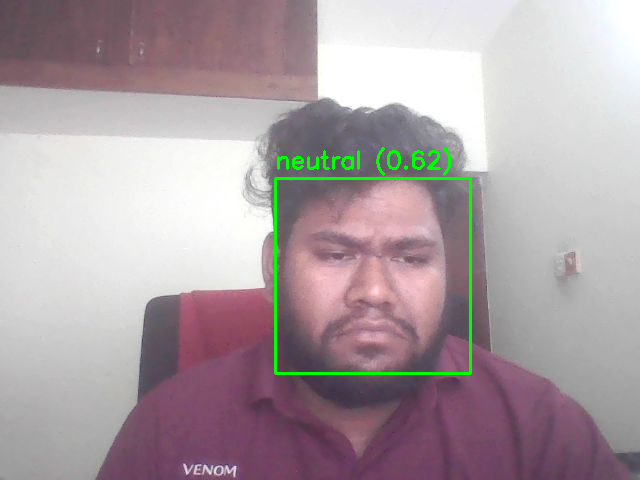


Emotion Confidence
Text Emotion    █████████████████ 0.85
Face Emotion    ████████████ 0.62

Text emotion : sadness (0.85)
Face emotion : neutral (0.62)
Final emotion: sadness (0.85)
Fusion mode  : text-priority
Conflict     : Yes
Mood trend   : insufficient-history
Strategy     : validate sadness, normalize emotional pain, gently explore the heaviest part
Safety mode  : normal-mode

Response     : I’m really sorry you’re carrying this right now. It can take time to process something painful like this. Sometimes putting the feeling into words can make it a little easier to carry. Would you like to share a little more about what happened?


In [32]:
result = multimodal_system("I lost my job today and I feel hopeless.")

<IPython.core.display.Javascript object>

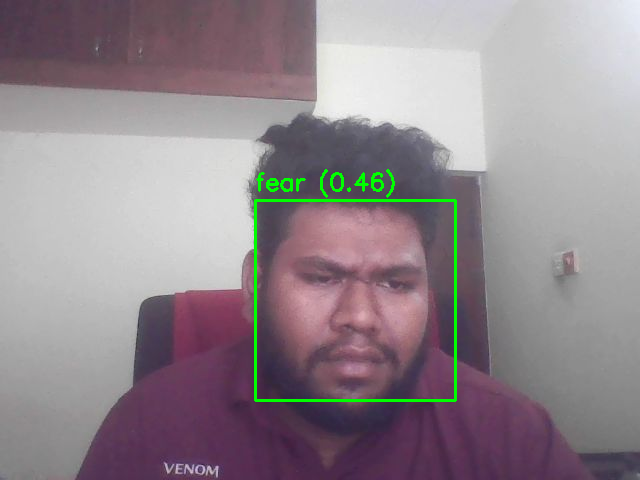


Emotion Confidence
Text Emotion    ████████████████ 0.81
Face Emotion    █████████ 0.46

Text emotion : sadness (0.81)
Face emotion : fear (0.46)
Final emotion: sadness (0.81)
Fusion mode  : text-priority
Conflict     : Yes
Mood trend   : emotional-fluctuation
Strategy     : acknowledge changing emotions, stay calm, offer grounding and simple reflection
Safety mode  : normal-mode

Response     : I’m really sorry you’re carrying this right now. It sounds like your emotions have been shifting over time. You do not have to force yourself to be okay straight away.


<IPython.core.display.Javascript object>

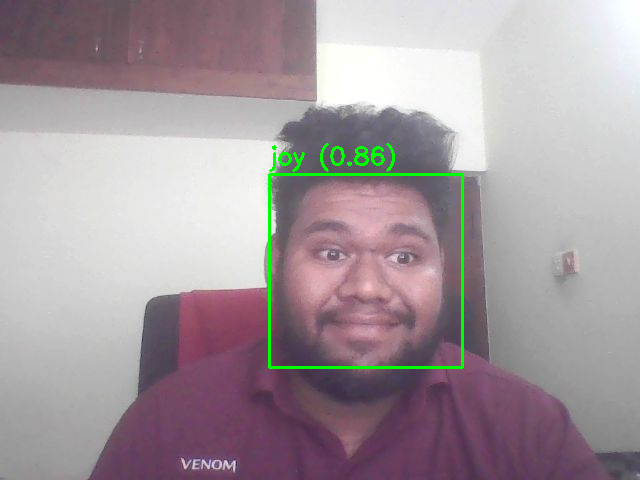


Emotion Confidence
Text Emotion    ██████████████████ 0.90
Face Emotion    █████████████████ 0.86

Text emotion : surprise (0.90)
Face emotion : joy (0.86)
Final emotion: surprise (0.90)
Fusion mode  : text-priority
Conflict     : Yes
Mood trend   : stable
Strategy     : acknowledge unexpectedness, help user make sense of event
Safety mode  : normal-mode

Response     : I can see why that caught you off guard. Unexpected moments can take time to make sense of. What stood out to you most about it?


<IPython.core.display.Javascript object>

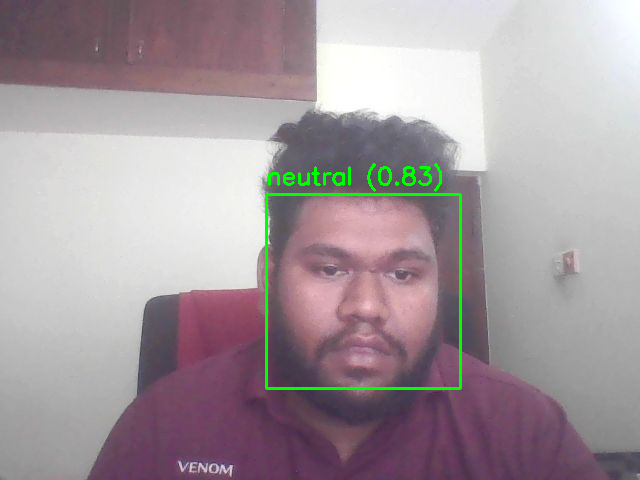


Emotion Confidence
Text Emotion    ██████████████████ 0.90
Face Emotion    ████████████████ 0.83

Text emotion : anger (0.90)
Face emotion : neutral (0.83)
Final emotion: anger (0.90)
Fusion mode  : text-priority
Conflict     : Yes
Mood trend   : stable
Strategy     : validate frustration, reduce escalation, encourage reflection on trigger
Safety mode  : normal-mode

Response     : That sounds really frustrating. Your reaction matters, and it is worth understanding what triggered it. What part of this upset you the most?


<IPython.core.display.Javascript object>

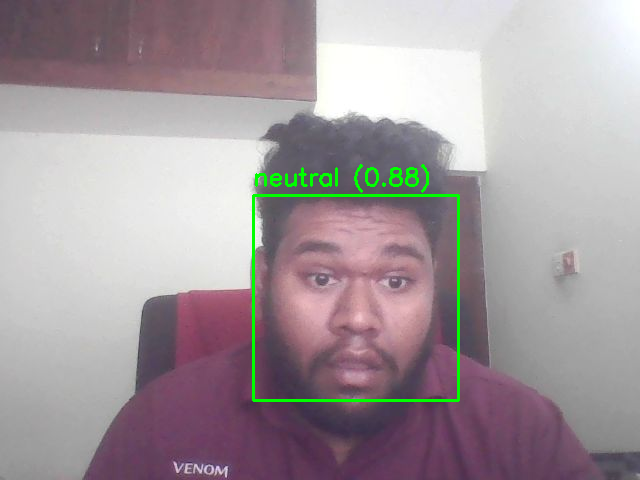


Emotion Confidence
Text Emotion    ██████████████████ 0.94
Face Emotion    █████████████████ 0.88

Text emotion : fear (0.94)
Face emotion : neutral (0.88)
Final emotion: fear (0.94)
Fusion mode  : text-priority
Conflict     : Yes
Mood trend   : emotional-fluctuation
Strategy     : acknowledge changing emotions, stay calm, offer grounding and simple reflection
Safety mode  : normal-mode

Response     : That sounds really scary. It seems like your feelings have been changing quite a bit recently. You do not have to solve everything at once right now. Focusing on one small next step can sometimes ease the pressure.


<IPython.core.display.Javascript object>

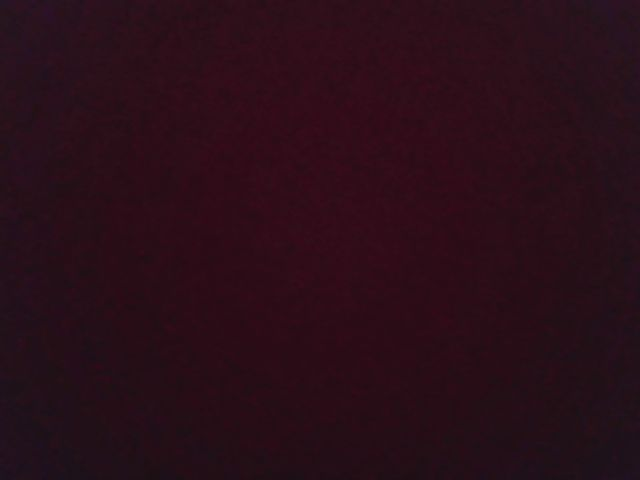


Emotion Confidence
Text Emotion    ████████████ 0.62

Text emotion : neutral (0.62)
Face emotion : No face detected
Final emotion: neutral (0.62)
Fusion mode  : text-only fallback
Conflict     : No
Mood trend   : emotional-fluctuation
Strategy     : acknowledge changing emotions, stay calm, offer grounding and simple reflection
Safety mode  : normal-mode

Response     : I appreciate you telling me that. It seems like these feelings have been staying with you for a while. Sometimes it helps to pause and notice how the day actually felt. Would you like to say a bit more about that?


In [43]:
result = multimodal_system("I feel like everything is going wrong in my life.")
result = multimodal_system("My friends surprised me with a party today!")
result = multimodal_system("I am so angry about what happened today.")
result = multimodal_system("I am really scared about what might happen next.")
result = multimodal_system("Today was a normal day for me.")

<IPython.core.display.Javascript object>

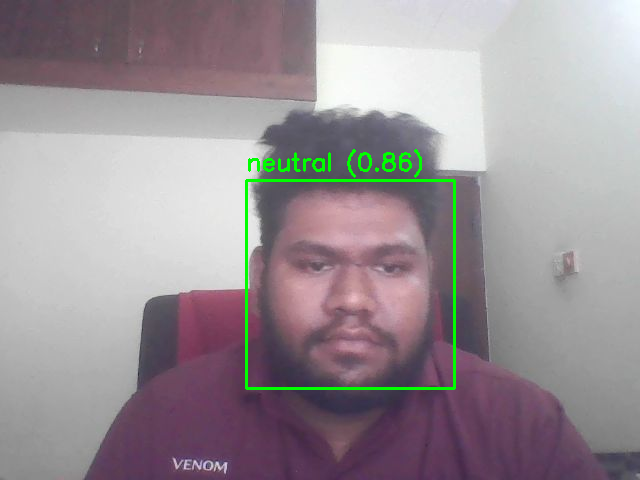


Emotion Confidence
Text Emotion    ████████████ 0.62
Face Emotion    █████████████████ 0.86

Text emotion : sadness (0.62)
Face emotion : neutral (0.86)
Final emotion: neutral (0.63)
Fusion mode  : weighted fusion
Conflict     : Yes
Mood trend   : emotional-fluctuation
Strategy     : acknowledge changing emotions, stay calm, offer grounding and simple reflection
Safety mode  : crisis-safe-mode

Response     : I’m really sorry you’re feeling this overwhelmed right now. Please contact Sri Lanka’s National Mental Health Helpline on 1926 or reach the National Institute of Mental Health on +94 11 257 8234–7 as soon as possible. If you feel unsafe right now, go to the nearest hospital or get immediate help from someone physically near you.


In [44]:
result = multimodal_system("I feel like I cannot go on anymore.")


In [45]:
print("Conversation history:")
for x in conversation_history:
    print("-", x)

print("\nEmotion history:")
for x in final_emotion_history:
    print("-", x)

print("\nFusion mode history:")
for x in fusion_mode_history:
    print("-", x)

Conversation history:
- My friends surprised me with a party today!
- I am so angry about what happened today.
- I am really scared about what might happen next.
- Today was a normal day for me.
- I feel like I cannot go on anymore.

Emotion history:
- surprise
- anger
- fear
- neutral
- neutral

Fusion mode history:
- text-priority
- text-priority
- text-priority
- text-only fallback
- weighted fusion
